Today's topics:
* `for` loops and indentation
* `range` and parallel lists
* `if`, `elif`, and `else`
* building a list of records

# Fatigue in steel

A steel specimen loaded once to 675 MPa doesn't break.
Cycle it between 675 MPa in tension and 675 MPa in compression, over and over, and it breaks after about seven thousand cycles.

Failure under repeated loading is called **fatigue**.
The stress **amplitude** is the distance from the mean stress to either end of that cycle, in MPa.

At a lower amplitude a part generally lasts more cycles.
Engineers plot stress amplitude against cycles in an **S-N chart**.

Today we will record how many cycles each test ran at its stress amplitude.

The data are from the [FABEST benchmark fatigue dataset](https://doi.org/10.5281/zenodo.20967342): 663 fatigue tests on 42CrMo4 steel, grouped into 60 test campaigns.

We use one campaign of seventeen specimens with the same shape and the same surface finish.
Each specimen was cycled at one amplitude until it broke or until the test was stopped.

## Read the campaign

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

tests = pd.read_csv('https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/fatigue_42crmo4.csv')
display(tests)

,curve_id,specimen_mark,specimen_type,surface_treatment,load_mode,fully_reversed,stress_amplitude_MPa,cycles,is_runout,point_comment
0,1,10,"solid bar, circular, unnotched",turned,push-pull,True,700.0,9290,False,crack (central part)
1,1,11,"solid bar, circular, unnotched",turned,push-pull,True,550.0,87107,False,broken
2,1,12,"solid bar, circular, unnotched",turned,push-pull,True,500.0,514828,False,"broken, metallography"
3,1,13,"solid bar, circular, unnotched",turned,push-pull,True,520.0,482531,False,crack (central part)
4,1,15,"solid bar, circular, unnotched",turned,push-pull,True,480.0,42761351,True,NaN
...,...,...,...,...,...,...,...,...,...,...
658,114,48,"solid bar, circular, unnotched",as heat-treated (no additional finishing),push-pull,False,600.0,249638,False,NaN
659,114,5,"solid bar, circular, unnotched",as heat-treated (no additional finishing),push-pull,False,675.0,29772,False,buckling?
660,114,50,"solid bar, circular, unnotched",as heat-treated (no additional finishing),push-pull,False,705.0,12647,False,buckling?
661,114,55,"solid bar, circular, unnotched",as heat-treated (no additional finishing),push-pull,False,625.0,164923,False,NaN


One row is one specimen.
`curve_id` identifies the test campaign.
Campaign 29 has seventeen specimens, more than any other campaign in the file.

Filter to campaign 29 with a mask, as in L11:

In [2]:
campaign = tests.loc[tests['curve_id'] == 29]
print(len(campaign))  # specimens in campaign 29

17


The source rows are not ordered by stress amplitude.
`.sort_values()` reorders the rows by one column, and `ascending=False` puts the highest stress first:

In [3]:
campaign = campaign.sort_values('stress_amplitude_MPa', ascending=False)
display(campaign)

,curve_id,specimen_mark,specimen_type,surface_treatment,load_mode,fully_reversed,stress_amplitude_MPa,cycles,is_runout,point_comment
188,29,1,"solid bar, circular, unnotched",turned,push-pull,True,675.0,6775,False,NaN
197,29,2B,"solid bar, circular, unnotched",turned,push-pull,True,650.0,15166,False,NaN
204,29,9,"solid bar, circular, unnotched",turned,push-pull,True,625.0,34667,False,NaN
200,29,5,"solid bar, circular, unnotched",turned,push-pull,True,575.0,53318,False,NaN
201,29,6,"solid bar, circular, unnotched",turned,push-pull,True,525.0,102666,False,NaN
202,29,7,"solid bar, circular, unnotched",turned,push-pull,True,500.0,95831,False,NaN
203,29,8,"solid bar, circular, unnotched",turned,push-pull,True,475.0,136602,False,NaN
199,29,4,"solid bar, circular, unnotched",turned,push-pull,True,462.5,148213,False,NaN
189,29,10,"solid bar, circular, unnotched",turned,push-pull,True,450.0,1873724,False,NaN
198,29,3,"solid bar, circular, unnotched",turned,push-pull,True,450.0,201089,False,NaN


We will use three columns: the stress amplitude, the cycle count, and `is_runout`.

The loops below run over plain Python lists (L07).
`.tolist()` turns a column into a list:

In [4]:
stress = campaign['stress_amplitude_MPa'].tolist()  # MPa
cycles = campaign['cycles'].tolist()
runout = campaign['is_runout'].tolist()             # True or False for each specimen

print(stress)

[675.0, 650.0, 625.0, 575.0, 525.0, 500.0, 475.0, 462.5, 450.0, 450.0, 425.0, 425.0, 400.0, 400.0, 375.0, 375.0, 350.0]


# `for` loops

We have seventeen stresses.
Printing each one by hand would take seventeen `print` lines, one per specimen.

In [5]:
for s in stress:
    print(s)

675.0
650.0
625.0
575.0
525.0
500.0
475.0
462.5
450.0
450.0
425.0
425.0
400.0
400.0
375.0
375.0
350.0


`for s in stress:` sets `s` to each entry of the list in turn and runs the indented block once per entry.
The colon ends the header, and the indentation marks the block.

## Indentation

Let's loop over just the first three stresses (a slice, as in L03) and add a line after the loop:

In [6]:
for s in stress[:3]:
    print(s, 'MPa')
print('done')  # not indented, so it runs once, after the loop

675.0 MPa
650.0 MPa
625.0 MPa
done


Now indent that last line, so it sits inside the block:

In [7]:
for s in stress[:3]:
    print(s, 'MPa')
    print('done')  # indented, so it runs every time round

675.0 MPa
done
650.0 MPa
done
625.0 MPa
done


`done` printed three times instead of once.

Python has no braces or `end` keyword around a block.
The indentation *is* the block, so moving a line in or out changes what the program does.

# range and parallel lists

From a stress value alone, we can't see how long its specimen lasted.
`stress[i]` and `cycles[i]` describe the same specimen, because both came from the same row of the table.
Lists that line up this way are **parallel**, like the arrays in L03.

To read them together, we loop over positions instead of values.
`range(3)` produces the positions 0, 1, and 2:

In [8]:
for i in range(3):
    print(i)

0
1
2


`range(n)` stops at n - 1, so it produces exactly the positions a list of length n has.
`len(stress)` is 17, so `range(len(stress))` runs from 0 to 16:

In [9]:
for i in range(len(stress)):
    print(stress[i], 'MPa', cycles[i], 'cycles')  # same position i in both lists

675.0 MPa 6775 cycles
650.0 MPa 15166 cycles
625.0 MPa 34667 cycles
575.0 MPa 53318 cycles
525.0 MPa 102666 cycles
500.0 MPa 95831 cycles
475.0 MPa 136602 cycles
462.5 MPa 148213 cycles
450.0 MPa 1873724 cycles
450.0 MPa 201089 cycles
425.0 MPa 908932 cycles
425.0 MPa 1188874 cycles
400.0 MPa 438028 cycles
400.0 MPa 1469859 cycles
375.0 MPa 3911774 cycles
375.0 MPa 4667019 cycles
350.0 MPa 33608010 cycles


As the stress amplitude falls, the cycle counts climb from thousands into the millions, with a lot of scatter between specimens tested at the same stress.

# if, elif, and else

## if

A comparison returns `True` or `False` (L11):

In [10]:
print(cycles[0] > 1000000)

False


`if` runs its block only when that result is `True`:

In [11]:
if cycles[0] > 1000000:
    print('more than a million cycles')

Nothing printed.
The specimen at position 0 lasted 6775 cycles, so the condition was `False` and the block was skipped.

The specimen at position 8 lasted longer:

In [12]:
if cycles[8] > 1000000:
    print('more than a million cycles')

more than a million cycles


## A counter

Put the `if` inside a loop to apply the same comparison to every specimen.
To count the answers, start a counter at zero before the loop and add one inside the `if`:

In [13]:
long_lived = 0  # start the count at zero

for c in cycles:
    if c > 1000000:
        long_lived = long_lived + 1  # inside the if, inside the for

print(long_lived)  # after the loop, so it prints once

6


Six of the seventeen specimens lasted more than a million cycles.

A mask from L11 counts the same thing without a loop.
Comparing the list itself fails, though:

In [14]:
# EXPECTED-ERROR: this cell fails on purpose -- see the surrounding text
cycles > 1000000

TypeError: '>' not supported between instances of 'list' and 'int'

`TypeError`: as in L07, `>` works elementwise on an array but not on a list.
`np.array()` converts it first:

In [15]:
print(np.sum(np.array(cycles) > 1000000))  # counts the True entries

6


The mask counts the same six specimens.

## else

One specimen in this campaign never broke.
Its test was stopped at 33,608,010 cycles with the specimen still intact, and that's called a **runout**.

Its cycle count isn't a life.
All we know is that at 350 MPa the specimen lasts *at least* 33,608,010 cycles.

With `else`, an `if` has a second block, which runs when the condition is `False`:

In [16]:
for i in range(len(stress)):
    if runout[i]:
        print(stress[i], 'MPa: stopped at', cycles[i], 'cycles, not broken')
    else:
        print(stress[i], 'MPa: broke at', cycles[i], 'cycles')

675.0 MPa: broke at 6775 cycles
650.0 MPa: broke at 15166 cycles
625.0 MPa: broke at 34667 cycles
575.0 MPa: broke at 53318 cycles
525.0 MPa: broke at 102666 cycles
500.0 MPa: broke at 95831 cycles
475.0 MPa: broke at 136602 cycles
462.5 MPa: broke at 148213 cycles
450.0 MPa: broke at 1873724 cycles
450.0 MPa: broke at 201089 cycles
425.0 MPa: broke at 908932 cycles
425.0 MPa: broke at 1188874 cycles
400.0 MPa: broke at 438028 cycles
400.0 MPa: broke at 1469859 cycles
375.0 MPa: broke at 3911774 cycles
375.0 MPa: broke at 4667019 cycles
350.0 MPa: stopped at 33608010 cycles, not broken


Exactly one of the two blocks runs for each specimen.

`runout[i]` is already `True` or `False`, so it needs no comparison.
Writing `if runout[i] == True:` also works, but the `== True` adds nothing.

## The S-N chart

Each specimen gets one point.
The runout gets a different marker, because its cycle count is a lower bound rather than a life.
Fatigue charts usually mark a runout with an arrow pointing right.

Text(0, 0.5, 'stress amplitude (MPa)')

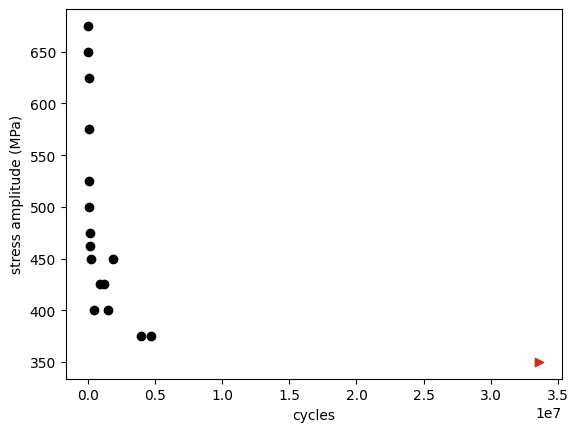

In [17]:
fig, ax = plt.subplots()

for i in range(len(stress)):
    if runout[i]:
        ax.scatter(cycles[i], stress[i], marker='>', color='tab:red')  # arrow: still intact when the test stopped
    else:
        ax.scatter(cycles[i], stress[i], color='black')

ax.set_xlabel('cycles')
ax.set_ylabel('stress amplitude (MPa)')

Sixteen of the points sit close to the left edge.
The runout at 33.6 million cycles sets the range of the axis, and the rest are under 5 million.

The cycle counts span about four powers of ten, so a log axis spreads them out.
`ax.set_xscale('log')` is the x-axis twin of `ax.set_yscale('log')` from L09:

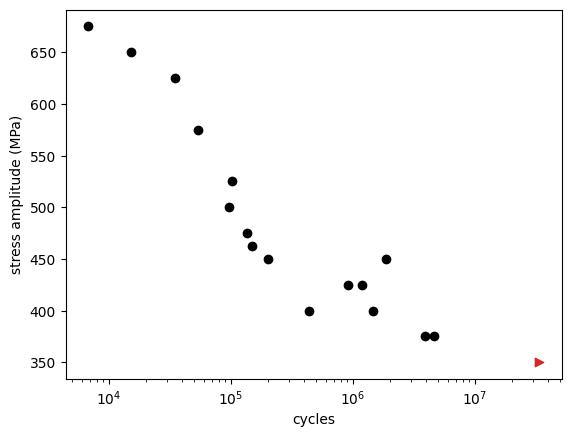

In [18]:
ax.set_xscale('log')  # each tick is ten times the last
fig  # draw the figure again

On the log axis, lower stress amplitudes go with more cycles, with scatter between specimens tested at the same stress.
The arrow points toward larger cycle counts because a later failure, if one occurred, was not observed.

### [Check your understanding]

1. Loop over `cycles` and print each value.
2. Loop with `range(len(cycles))` and print the stress and the cycles for each specimen that broke, using `runout[i] == False` to skip the runout.
3. Count the specimens that lasted fewer than 100000 cycles, twice: once with a counter and an `if`, once with a mask and `np.sum`.
4. In a comment, write what we know about the runout specimen's life as an inequality.

*Why can't 33,608,010 cycles be reported as that specimen's life?*

## elif

Fatigue engineers divide the S-N curve into **low-cycle fatigue** at short lives and **high-cycle fatigue** at long ones.
For this programming example, we label the tests by cycle count.

The boundaries are a convention.
Here we put the boundary at 100000 cycles and call anything past 5000000 cycles long-life.

`elif` (short for "else if") adds conditions between `if` and `else`.
Python checks them from the top and runs only the first block whose condition is `True`:

In [19]:
for i in range(len(stress)):
    if cycles[i] < 100000:
        region = 'low-cycle'
    elif cycles[i] < 5000000:
        region = 'high-cycle'  # only checked when cycles[i] >= 100000
    else:
        region = 'long-life'
    print(stress[i], 'MPa:', region)

675.0 MPa: low-cycle
650.0 MPa: low-cycle
625.0 MPa: low-cycle
575.0 MPa: low-cycle
525.0 MPa: high-cycle
500.0 MPa: low-cycle
475.0 MPa: high-cycle
462.5 MPa: high-cycle
450.0 MPa: high-cycle
450.0 MPa: high-cycle
425.0 MPa: high-cycle
425.0 MPa: high-cycle
400.0 MPa: high-cycle
400.0 MPa: high-cycle
375.0 MPa: high-cycle
375.0 MPa: high-cycle
350.0 MPa: long-life


Five specimens are low-cycle, eleven are high-cycle, and the one long-life entry is the runout.

Each label depends only on the cycle count.
Here "long-life" means the test ran past five million cycles, not that a specimen broke there.

# A list of records

Three parallel lists stay aligned only if we change all three together.
In L07 we kept labeled values together in a dictionary.

A loop can build one dictionary per specimen, and `.append()` adds each one to the end of a list:

In [20]:
specimens = []  # start with an empty list

for i in range(len(stress)):
    specimens.append({'stress': stress[i], 'cycles': cycles[i], 'runout': runout[i]})

print(len(specimens))  # one record per specimen
print(specimens[0])

17
{'stress': 675.0, 'cycles': 6775, 'runout': False}


Each record has its own labels, so a loop over `specimens` needs no position:

In [21]:
for sp in specimens:
    if sp['runout']:
        print(sp['stress'], 'MPa: not broken')

350.0 MPa: not broken


### [Check your understanding]

1. Loop over `specimens` and print the stress of every specimen that lasted fewer than 100000 cycles.
2. Build a list called `lives` holding the cycles of the specimens that broke, using a loop, an `if`, and `.append()`.
   `sp['runout'] == False` is `True` for a specimen that broke.
3. Print `len(lives)` and `np.median(lives)`.

*Why does the median of `lives` describe something different from the median of `cycles`?*

# Summary

On `for` loops:
* `for x in things:` runs the indented block once per entry.
* A line indented under the `for` runs every time round, and a line after the block runs once.
* A counter set to zero before the loop and updated inside it accumulates a total.

On `range`:
* `for i in range(len(things)):` loops over positions, which is how parallel lists are read together.

On `if`, `elif`, and `else`:
* `if` runs its block only when the condition is `True`, and `else` runs when it is `False`.
* With `elif`, Python runs only the first block whose condition is `True`.

On records:
* A loop with `.append()` builds a list of dictionaries, one per specimen.

At 350 MPa the specimen was still intact after 33,608,010 cycles.
Its failure life is therefore greater than 33,608,010 cycles.

## Further reading

* VanderPlas, *A Whirlwind Tour of Python*, "Control Flow"
* The data: FABEST benchmark fatigue dataset, [Zenodo 10.5281/zenodo.20967342](https://doi.org/10.5281/zenodo.20967342), CC BY 4.0